In [746]:
import hydra
import numpy as np
from tqdm import tqdm
from workspace import MiniGridWorkspace
from absl import logging
import jax
import jax.numpy as jnp
import wandb
import chex
import itertools
from scipy.stats import pearsonr, spearmanr
import os
from typing import Any, Optional, Tuple, Literal, Mapping, Text

from omegaconf import DictConfig, OmegaConf

from helpers import training_loop, eval_loop, trackers, logging_and_metrics

Array = chex.Array
Numeric = chex.Numeric

In [747]:
from hydra.core.global_hydra import GlobalHydra

# Clear existing Hydra instance if already initialized
if GlobalHydra.instance().is_initialized():
    GlobalHydra.instance().clear()

# Initialize Hydra and load the config directly
hydra.initialize(config_path="../", version_base=None)
cfg = hydra.compose(config_name="post_train_sf_analysis")

In [748]:
#Set Seed
cfg.train.seed = 485
# Set Action
action = 2 # 0 - left, 1 - right, 2 - forward

# Set task_id
task_id = 0

# set to True if use other discount values other than 0.99
cfg.snapshot.use_alternate_discount = False

if cfg.snapshot.use_alternate_discount:
    cfg.domain.discount = 0.5

if cfg.agent.name == "aps_sparsify_agent":
    cfg.agent.reg_sf = 0.1

    decimal_reg_sf = str(cfg.agent.reg_sf).split(".")[1]
    cfg.snapshot.snapshot_dir = os.path.join(
        cfg.snapshot.snapshot_dir,
        "reg_sf_" + decimal_reg_sf
            )


In [749]:
action_names = {0: 'left', 1: 'right', 2: 'forward'}
chosen_action_name = action_names[action]
gaussian_smoothing = False
guassian_sigma = 0.8 # default is 1.0
erode_dilate = False
morph_filter_mode = "opening"
gaussian_smooth_then_erode_dilate = True

In [750]:
# Print the loaded config
print(OmegaConf.to_yaml(cfg))

agent:
  _target_: agent.simple_sf_agent.SimpleSFAgent
  action_shape: ???
  action_repeat: ${env.action_repeat}
  batch_size: ${domain.replay.batch_size}
  critic_target_tau: 0.01
  double_q_learning: true
  encoder_type: default
  feature_dim: ${train.feature_dim}
  grad_error_bound: ${train.grad_error_bound}
  has_task_params: true
  hidden_dim: 256
  learn_period: ${train.learn_period}
  min_replay_capacity_fraction: ${replay.min_replay_capacity_fraction}
  name: simple_sf_agent
  normalize_task_params: false
  nstep: ${replay.nstep}
  obs_shape: ${env.obs_shape}
  obs_type: ${env.obs_type}
  policy: learned
  replay_buffer_size: ${domain.replay.replay_buffer_size}
  reward_free: false
  sf_dim: ${train.sf_dim}
  use_double_q: ${train.use_double_q}
  update_encoder: true
  use_wandb: ${logging.use_wandb}
  lr: ${train.lr}
  optimizer: ${train.optimizer}
  optimizer_b_1: ${train.optimizer_b_1}
  optimizer_b_2: ${train.optimizer_b_2}
  lr_task: ???
  optimizer_task: ${train.optimizer

In [751]:
def contains_nan(params):
    for name, value in params.items():
        if isinstance(value, dict):
            if contains_nan(value):  # Recursively check for nested parameters
                return True
        elif np.any(np.isnan(jax.device_get(value))):
            print(f"NaN found in {name}")
            return True
    return False

In [752]:
# Normalize the snapshot_dir path
base_path = "/Users/raymondchua/Documents/CRL_flax/"
cfg.snapshot.snapshot_dir = os.path.abspath(os.path.join(base_path, cfg.snapshot.snapshot_dir))

if cfg.snapshot.use_alternate_discount:
    cfg.snapshot.snapshot_dir = os.path.abspath(os.path.join(cfg.snapshot.snapshot_dir, "discount_"+str(cfg.domain.discount)))

print("Updated snapshot_dir:", cfg.snapshot.snapshot_dir)

Updated snapshot_dir: /Users/raymondchua/Documents/CRL_flax/models/full_train_minigrid/TwoRoomsLargeTwoTasks/simple_sf_agent/485


In [753]:
# load sf_tuning_curve numpy matrix
sf_tuning_curve_path = os.path.join(cfg.snapshot.snapshot_dir, f"sf_tuning_curve_task{task_id}.npy")
sf_tuning_curve_matrix = np.load(sf_tuning_curve_path)

In [754]:
print(sf_tuning_curve_matrix.shape)
print(sf_tuning_curve_matrix[0, :, :, 1])



(7, 22, 22, 128)
[[        nan         nan         nan         nan         nan         nan
          nan         nan         nan         nan         nan         nan
          nan         nan         nan         nan         nan         nan
          nan         nan         nan         nan]
 [        nan         nan  0.16871294  0.15924195  0.15618132  0.2339097
   0.23216461  0.19810707  0.1396836   0.1984032   0.13631624  0.29883919
   0.18326377  0.15071282  0.2370879   0.1832711   0.18936832  0.21543889
   0.15352351  0.17730394  0.15301085         nan]
 [        nan  0.23340634  0.09302206  0.20564565  0.07365164  0.21013256
   0.09897334  0.10406309  0.12841635  0.118867    0.13793469  0.09073597
   0.1127752   0.2005128   0.10783693  0.14074801  0.10889015  0.16151094
   0.12695793  0.15934566  0.1591526          nan]
 [        nan  0.16697685  0.07795737  0.05939643  0.1135986   0.06150137
   0.06991417  0.10847219  0.11336534  0.09133157  0.11881521  0.10384223
   0.07152074  0.

In [755]:
workspace = MiniGridWorkspace(cfg)
goal_pos = workspace.goal_pos(task_id)

# offset the goal pos to account for the border of the original minigrid size
goal_pos_x = goal_pos[0] - 1
goal_pos_y = goal_pos[1] - 1
goal_pos_corrected = (goal_pos_x, goal_pos_y)
print("goal_pos: ", goal_pos)
print("goal pos corrected:", goal_pos_corrected)

GoalVis
bot state:  (11, 20)
sample_network_input_extended shape:  (1, 84, 84, 3)
goal_pos:  (1, 1)
goal pos corrected: (0, 0)


In [756]:
def morph_filter(binary_map, structure_size=3, mode='closing'):
    """
    Apply morphological filtering to a binary map.
    Parameters:
        binary_map: 2D np.array of 0s and 1s
        structure_size: size of the structuring element
        mode: 'erode', 'dilate', 'opening', 'closing'
    Returns:
        filtered binary map
    """
    from scipy.ndimage import generate_binary_structure
    # from skimage.morphology import disk

    struct = generate_binary_structure(2, 1)  # 4-connectivity
    # struct = disk(radius=2)  # radius=2 ~ 5x5 kernel
    if structure_size > 1:
        from scipy.ndimage import iterate_structure
        struct = iterate_structure(struct, structure_size)

    if mode == 'erode':
        return binary_erosion(binary_map, structure=struct)
    elif mode == 'dilate':
        return binary_dilation(binary_map, structure=struct)
    elif mode == 'opening':
        return binary_dilation(binary_erosion(binary_map, structure=struct), structure=struct)
    elif mode == 'closing':
        return binary_erosion(binary_dilation(binary_map, structure=struct), structure=struct)
    else:
        raise ValueError("Invalid mode: choose 'erode', 'dilate', 'opening', or 'closing'")

In [757]:
from helpers import nan_gaussian_filter, compute_spatial_info_rate, compute_sparsity
from scipy.ndimage import gaussian_filter, label, binary_erosion, binary_dilation, grey_erosion, grey_dilation
from skimage.measure import regionprops


num_cells = sf_tuning_curve_matrix.shape[3]

if num_cells < 8:
    num_cols = num_cells
else:
    num_cols = 8

num_rows = num_cells // num_cols

if num_rows == 0:
    num_rows = 1

information_rate_all_cells = []
sparsity_all_cells = []
selected_i = []
selected_j = []
sf_processed = []
unit_visuals = []

assert sum([gaussian_smoothing, erode_dilate, gaussian_smooth_then_erode_dilate]) == 1, \
    "Exactly one smoothing option must be True"


for i in range(num_rows):
    for j in range(num_cols):

        cell_idx = i * num_cols + j
        sf_current_cell = sf_tuning_curve_matrix[action, :, :, cell_idx]
        sf_current_cell = sf_current_cell.T

        # remove the border
        # sf_current_cell = sf_current_cell[1:-1, 1:-1]



        # z-score the sf_current_cell
        # sf_current_cell = sf_current_cell - np.mean(sf_current_cell) / np.std(
        #     sf_current_cell
        # )

        sf_min = np.nanmin(sf_current_cell)
        sf_max = np.nanmax(sf_current_cell)
        sf_normalized = (sf_current_cell - sf_min) / (sf_max - sf_min + 1e-10)

        sf_norm = np.linalg.norm(np.nan_to_num(sf_normalized))

        # if the norm of the sf_current_cell is zero, then we skip
        if sf_norm == 0:
            # print("sf_norm is zero for cell {i}, {j}".format(i=i, j=j))
            # max_value = np.max(sf_current_cell)
            # print("max_value: ", max_value)
            continue

        threshold = np.nanpercentile(sf_normalized, 95)  # top 15% activity
        binary_map = (sf_normalized > threshold).astype(int)

        if gaussian_smoothing:
            sf_normalized = nan_gaussian_filter(sf_normalized, sigma=guassian_sigma)

        elif erode_dilate:
            nan_mask = np.isnan(sf_normalized)

            # Fill NaNs temporarily with neutral value
            sf_filled = np.where(nan_mask, 0, sf_normalized)  # 0 is neutral for morphological ops
            sf_normalized = grey_erosion(grey_dilation(sf_filled, size=(5,5)), size=(5,5))
            sf_normalized[nan_mask] = np.nan

        elif gaussian_smooth_then_erode_dilate:
            sf_normalized = nan_gaussian_filter(sf_normalized, sigma=guassian_sigma)

            nan_mask = np.isnan(sf_normalized)
            sf_filled = np.where(nan_mask, 0, sf_normalized)  # 0 is neutral for morphological ops
            sf_normalized = grey_erosion(grey_dilation(sf_filled, size=(3,3)), size=(3,3))
            sf_normalized[nan_mask] = np.nan

        structure = np.ones((3, 3))  # 8-connectivity
        labeled_map, num_fields = label(binary_map, structure=structure)

        print("labeled map shape: ", labeled_map.shape)

        place_fields = []
        region_stats = regionprops(labeled_map, intensity_image=sf_normalized)

        # calculate the information rate of the cell, remove nan values
        cell_information_rate = compute_spatial_info_rate(sf_normalized)

        # calculate the sparsity index of the cell
        cell_sparsity = compute_sparsity(sf_normalized)

        information_rate_all_cells.append(cell_information_rate)
        sparsity_all_cells.append(cell_sparsity)

        selected_i = []
        selected_j = []
        sf_processed = []

        for region in region_stats:
            area = region.area
            if area >= 3:  # Filter out small/noisy fields
                props = {
                    'label': region.label,
                    'area': area,
                    'peak_z': region.max_intensity,
                    'mean_z': region.mean_intensity,
                    'center_of_mass': region.weighted_centroid,  # (y, x)
                    'bbox': region.bbox,  # (min_row, min_col, max_row, max_col)
                    'eccentricity': region.eccentricity,
                    'orientation': region.orientation,  # radians, relative to horizontal
                    'solidity': region.solidity,
                    'mask': (labeled_map == region.label),
                    'info_rate': cell_information_rate,
                    'sparsity': cell_sparsity,
                }
                place_fields.append(props)

        unit_visuals.append({
            'cell_idx': cell_idx,
            'sf_map': sf_normalized.copy(),
            'info_rate': cell_information_rate,
            'sparsity': cell_sparsity,
            'place_fields': place_fields,
        })

unit_visuals_sorted = sorted(unit_visuals, key=lambda x: x['info_rate'], reverse=True)

labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map shape:  (22, 22)
labeled map sh

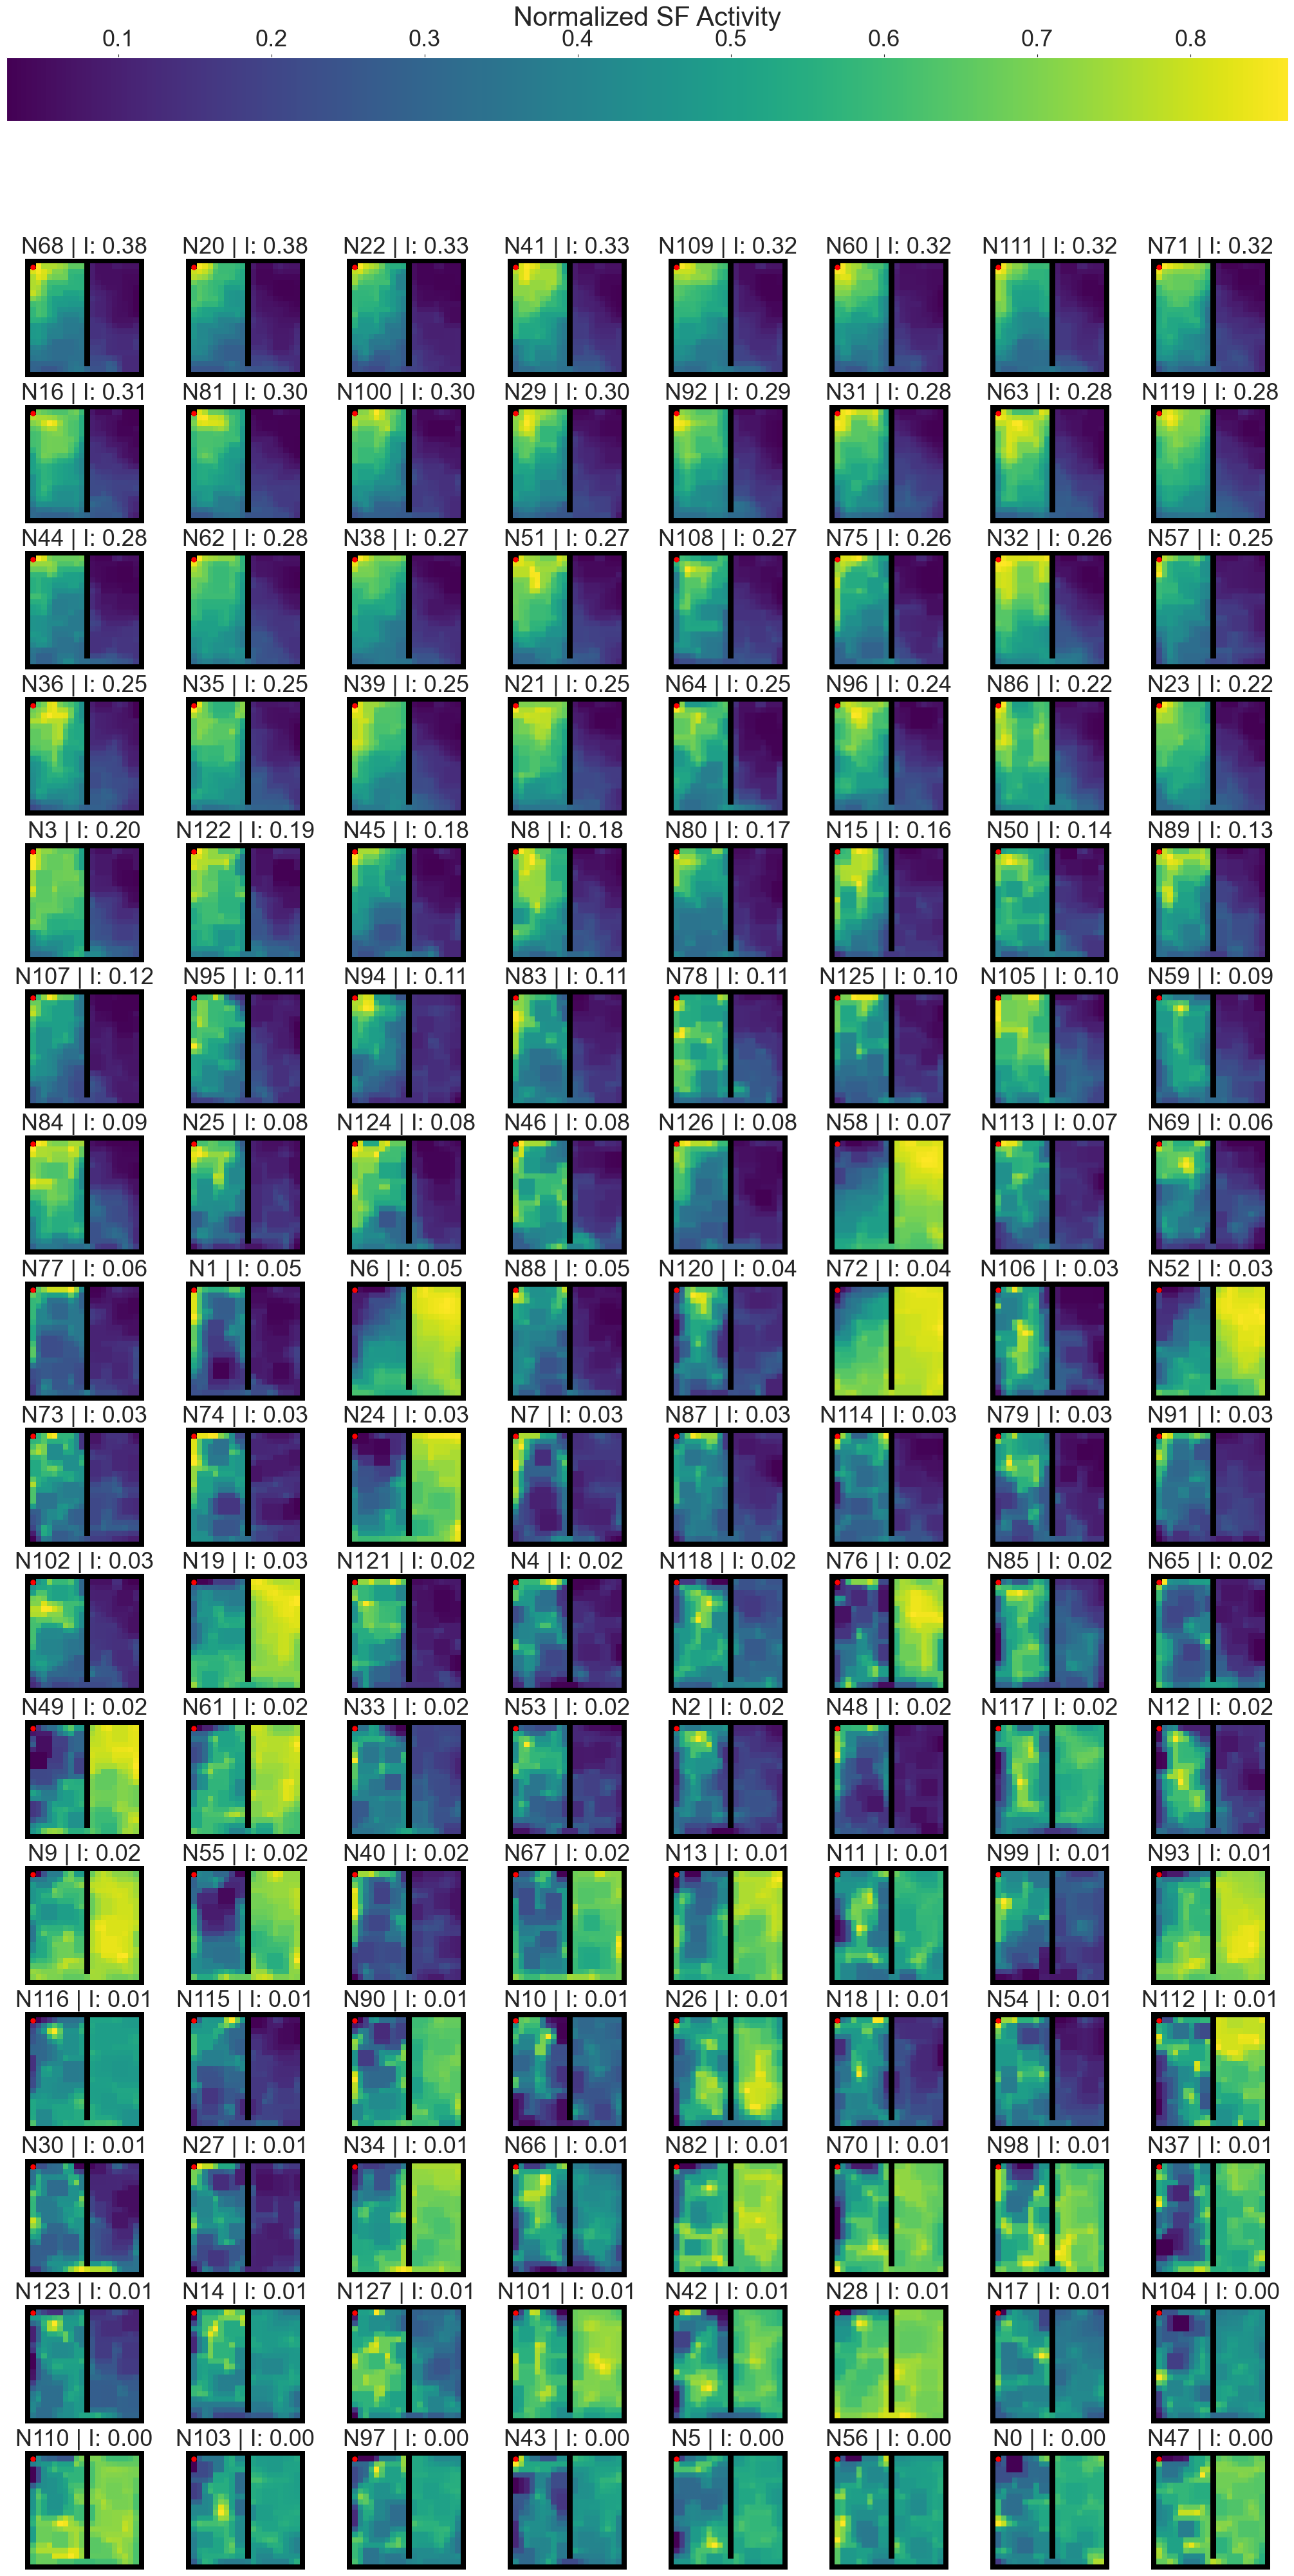

In [758]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

num_units = len(unit_visuals_sorted)
num_cols = 8
num_rows = int(np.ceil(num_units / num_cols))

# fig, axs = plt.subplots(num_rows, num_cols, figsize=(2.5*num_cols, 2.5*num_rows))
fig, axs = plt.subplots(num_rows, num_cols, figsize=(2.5*num_cols, 2.5*num_rows), constrained_layout=True)
cmap = cm.get_cmap('viridis').copy()  # or 'plasma', 'inferno', etc.
cmap.set_bad(color='black')

for idx, unit in enumerate(unit_visuals_sorted):
    row = idx // num_cols
    col = idx % num_cols
    ax = axs[row, col]

    im = ax.imshow(unit['sf_map'], cmap=cmap)
    sf_map_masked = np.ma.masked_invalid(unit['sf_map'])

    # for f in unit['place_fields']:
    #     y, x = f['center_of_mass']
    #     ax.plot(x, y, 'ro', markersize=3)
    #     ax.contour(f['mask'], levels=[0.5], colors='red', linewidths=1)

    ax.set_title(f"N{unit['cell_idx']} | I: {unit['info_rate']:.2f}", fontsize=26)
    ax.axis('off')
    ax.plot(goal_pos_corrected[0] + 1, goal_pos_corrected[1] + 1, marker='o', color='red', markersize=5)
    # ax.text(goal_pos_corrected[0] + 3, goal_pos_corrected[1] + 3, 'Goal', color='red', ha='center', va='center', fontsize=18)

# Remove unused axes
for idx in range(len(unit_visuals_sorted), num_rows * num_cols):
    axs.flat[idx].axis('off')

# Use the last imshow as reference for color scale
sf_map_masked = np.ma.masked_invalid(unit_visuals_sorted[0]['sf_map'])
cmap = plt.cm.get_cmap('viridis').copy()
cmap.set_bad(color='black')

# Create a hidden AxesImage to grab the color scale
dummy_img = axs[0, 0].imshow(sf_map_masked, cmap=cmap)

# # Add one horizontal colorbar above the grid
# cbar_ax = fig.add_axes([0.3, 0.92, 0.4, 0.02])  # [left, bottom, width, height]
# One shared colorbar at the top with constrained_layout
cbar = fig.colorbar(dummy_img, ax=axs, orientation='horizontal', location='top')
cbar.set_label('Normalized SF Activity', fontsize=30)
cbar.ax.tick_params(labelsize=26)


# plt.tight_layout()
if gaussian_smoothing:
    fig.savefig(f"{cfg.snapshot.snapshot_dir}/sf_grid_action_{chosen_action_name}_seed{cfg.train.seed}_step{cfg.domain.train.num_train_frames}_smooth{gaussian_smoothing}.pdf")
elif erode_dilate:
    fig.savefig(f"{cfg.snapshot.snapshot_dir}/sf_grid_action_{chosen_action_name}_seed{cfg.train.seed}_step{cfg.domain.train.num_train_frames}_erode{erode_dilate}.pdf")
elif gaussian_smooth_then_erode_dilate:
    fig.savefig(f"{cfg.snapshot.snapshot_dir}/sf_grid_action_{chosen_action_name}_seed{cfg.train.seed}_step{cfg.domain.train.num_train_frames}_gaussian_smooth_then_erode_dilate{gaussian_smooth_then_erode_dilate}.pdf")
else:
    fig.savefig(f"{cfg.snapshot.snapshot_dir}/sf_grid_action_{chosen_action_name}_seed{cfg.train.seed}_step{cfg.domain.train.num_train_frames}.pdf")
plt.show()

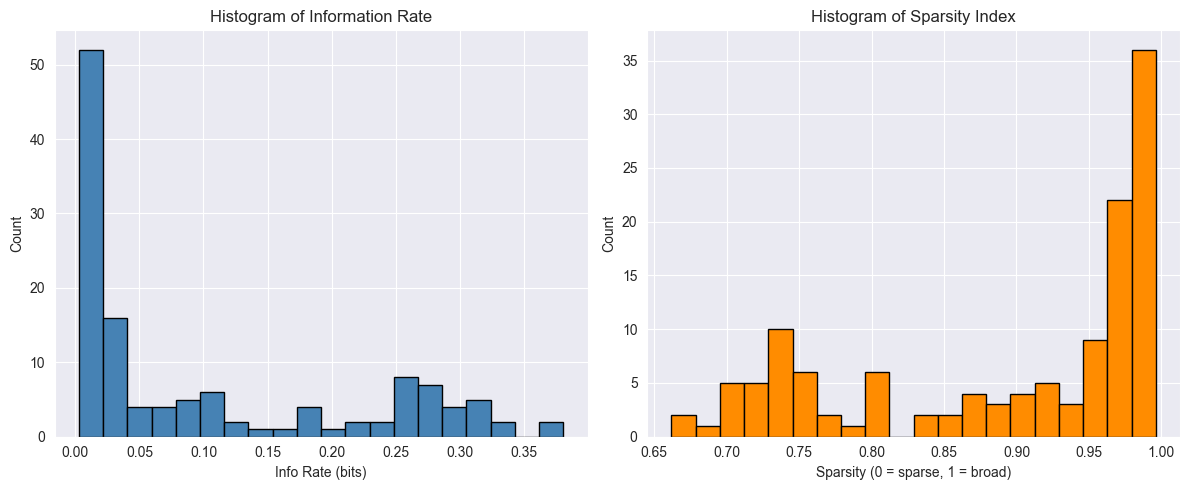

In [759]:
plt.close()
fig = plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(information_rate_all_cells, bins=20, color='steelblue', edgecolor='black')
plt.title("Histogram of Information Rate")
plt.xlabel("Info Rate (bits)")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.hist(sparsity_all_cells, bins=20, color='darkorange', edgecolor='black')
plt.title("Histogram of Sparsity Index")
plt.xlabel("Sparsity (0 = sparse, 1 = broad)")
plt.ylabel("Count")

plt.tight_layout()
fig.savefig(f"{cfg.snapshot.snapshot_dir}/sf_grid_action_{chosen_action_name}_seed{cfg.train.seed}_step{cfg.domain.train.num_train_frames}_information_rate_and_sparsity_histogram.pdf")
plt.show()

In [760]:
import pandas as pd
from pathlib import Path

snapshot_dir = Path(cfg.snapshot.snapshot_dir)
csv_path = snapshot_dir / f"info_stats_seed{cfg.train.seed}_action_{chosen_action_name}.csv"

df = pd.DataFrame({
    'cell_idx': list(range(len(information_rate_all_cells))),
    'info_rate': information_rate_all_cells,
    'sparsity': sparsity_all_cells,
    'seed': cfg.train.seed,
})

df.to_csv(csv_path, index=False)

In [761]:
all_areas = []
all_eccentricities = []
all_info_rate = []
all_sparsity = []
all_orientation = []

for unit in unit_visuals:
    for field in unit['place_fields']:
        all_areas.append(field['area'])
        all_eccentricities.append(field['eccentricity'])
        all_info_rate.append(field['info_rate'])
        all_sparsity.append(field['sparsity'])
        if not np.isnan(field['orientation']):
            all_orientation.append(field['orientation'])


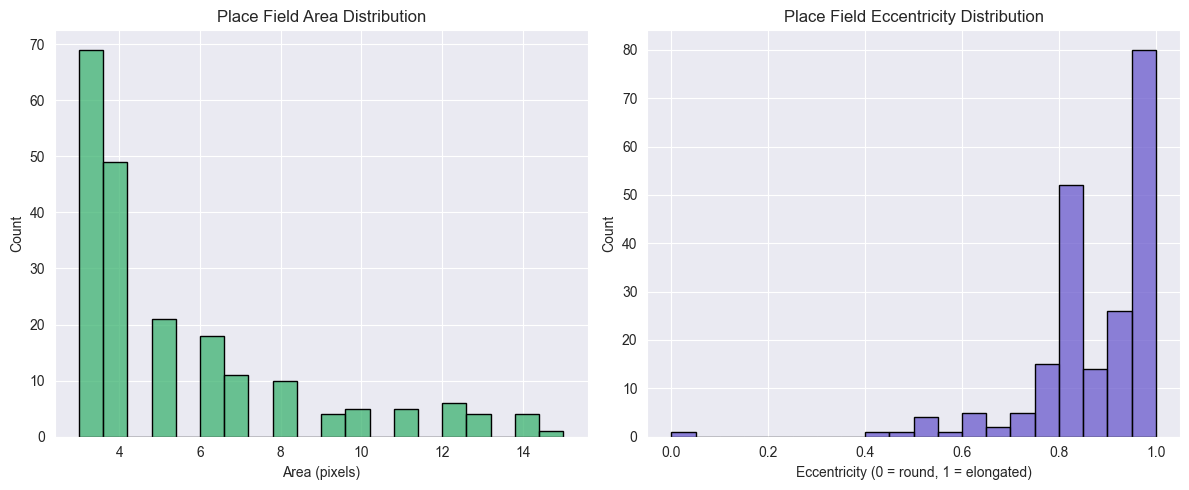

In [762]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.close()
fig = plt.figure(figsize=(12, 5))

# Area
plt.subplot(1, 2, 1)
sns.histplot(all_areas, bins=20, color='mediumseagreen', edgecolor='black')
plt.title("Place Field Area Distribution")
plt.xlabel("Area (pixels)")
plt.ylabel("Count")

# Eccentricity
plt.subplot(1, 2, 2)
sns.histplot(all_eccentricities, bins=20, color='slateblue', edgecolor='black')
plt.title("Place Field Eccentricity Distribution")
plt.xlabel("Eccentricity (0 = round, 1 = elongated)")
plt.ylabel("Count")

plt.tight_layout()
fig.savefig(f"{cfg.snapshot.snapshot_dir}/sf_grid_action_{chosen_action_name}_seed{cfg.train.seed}_step{cfg.domain.train.num_train_frames}_field_area_and_eccentricity_histogram.pdf")
plt.show()

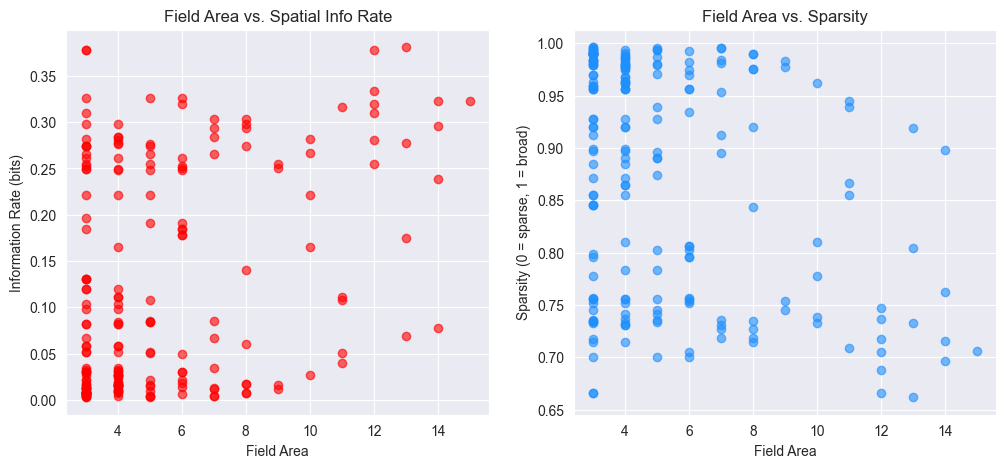

In [763]:
plt.close()
fig = plt.figure(figsize=(12, 5))

# Area
plt.subplot(1, 2, 1)
plt.scatter(
    all_areas,
    all_info_rate,
    alpha=0.6,
    color='red'
)
plt.xlabel("Field Area")
plt.ylabel("Information Rate (bits)")
plt.title("Field Area vs. Spatial Info Rate")

plt.subplot(1, 2, 2)
plt.scatter(
    all_areas,
    all_sparsity,
    alpha=0.6,
    color='dodgerblue'
)
plt.xlabel("Field Area")
plt.ylabel("Sparsity (0 = sparse, 1 = broad)")
plt.title("Field Area vs. Sparsity")
fig.savefig(f"{cfg.snapshot.snapshot_dir}/sf_grid_action_{chosen_action_name}_seed{cfg.train.seed}_step{cfg.domain.train.num_train_frames}_field_area_vs_spatial_info_and_sparsity_scatterplots.pdf")
plt.show()

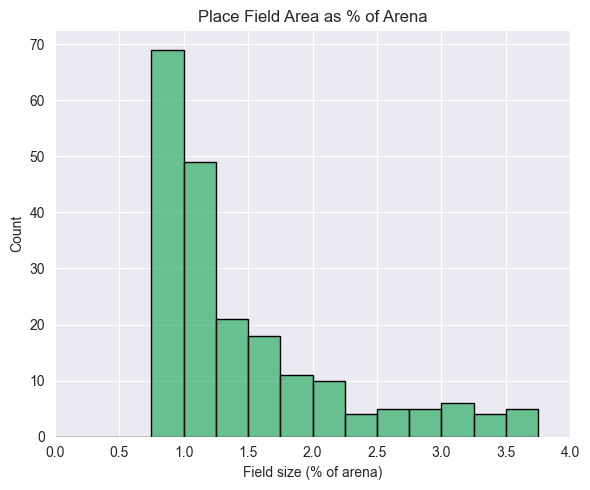

In [764]:
plt.close()
fig, ax = plt.subplots(figsize=(6, 5))

# arena size = 20 x 20
arena_area = (cfg.domain.grid_size-2) * (cfg.domain.grid_size-2)
areas = np.asarray(all_areas, dtype=float)
pct_of_arena = (areas / arena_area) * 100.0

# compute max and step size
max_val = np.max(pct_of_arena)
bin_width = 0.25   # choose your resolution
bins = np.arange(0, max_val + bin_width, bin_width)

sns.histplot(pct_of_arena, bins=bins, color='mediumseagreen', edgecolor='black')
ax.set_title("Place Field Area as % of Arena")
ax.set_xlabel("Field size (% of arena)")
ax.set_ylabel("Count")
ax.set_xlim(0, max_val + bin_width)

fig.tight_layout()
fig.savefig(
    f"{cfg.snapshot.snapshot_dir}/sf_grid_action_{chosen_action_name}_seed{cfg.train.seed}_"
    f"step{cfg.domain.train.num_train_frames}_field_area_percentage_histogram.pdf"
)
plt.show()

In [765]:
# workspace = MiniGridWorkspace(cfg)
# goal_pos = workspace.goal_pos(task_id)
#
# # offset the goal pos to account for the border of the original minigrid size
# goal_pos_x = goal_pos[0] - 1
# goal_pos_y = goal_pos[1] - 1
# goal_pos_corrected = (goal_pos_x, goal_pos_y)
# print("goal pos:", goal_pos_corrected)

sf_map = unit_visuals[0]['sf_map']

y: 1.0, x: 8.026740911196725
y: 5.995028995804719, x: 1.228020067096694
y: 10.005335334197701, x: 1.0
y: 2.9602818649838563, x: 4.1950690846043965
y: 1.2994653147097104, x: 7.21919918155567
y: 6.695817788192828, x: 7.6594200389230656
y: 12.669041531084279, x: 1.3162197344081772
y: 3.642571540738065, x: 5.961472618297893
y: 16.712244103425, x: 7.178205099441971
y: 1.7982141959675675, x: 14.398888069702751
y: 3.819288480693322, x: 18.180215880167363
y: 2.0256220791320048, x: 2.0
y: 6.032595055141865, x: 1.7707348448287934
y: 11.409535089235682, x: 1.0
y: 2.4946790411928106, x: 4.7969730617266535
y: 6.617098561293783, x: 2.3398104534554864
y: 14.80025933921601, x: 14.00340313126221
y: 1.9700568730539105, x: 2.661127554094667
y: 5.05940302319379, x: 6.029782509974821
y: 5.258596060373781, x: 6.760333221649576
y: 7.24521677847295, x: 4.732513995191972
y: 2.9876455532817023, x: 4.50370733513629
y: 5.749791605390158, x: 4.517813356518686
y: 3.6223548851612355, x: 5.482451476202746
y: 6.737231

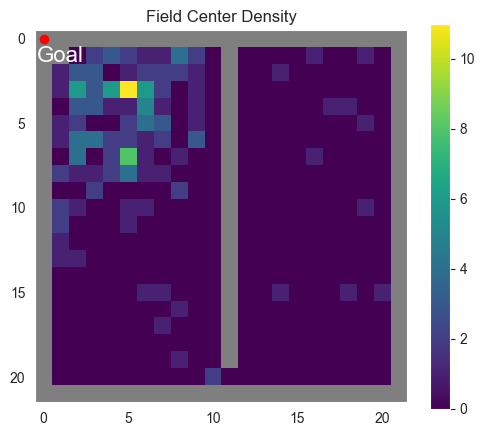

In [766]:
plt.close()
fig, ax = plt.subplots(figsize=(6, 5))

heatmap = np.zeros((cfg.domain.grid_size, cfg.domain.grid_size))

for unit in unit_visuals:
    for field in unit['place_fields']:
        y, x = field['center_of_mass']
        if not np.isnan([x, y]).any():
            heatmap[int(round(y)), int(round(x))] += 1
            print("y: {}, x: {}".format(y, x))

heatmap[np.isnan(sf_map)] = np.nan
plt.plot(goal_pos_corrected[0], goal_pos_corrected[1], marker='o', color='red', markersize=6)
plt.text(goal_pos_corrected[0] + 1, goal_pos_corrected[1] + 1, 'Goal', color='white', ha='center', va='center', fontsize=16)
plt.grid(False)
tick_locs = np.arange(0, cfg.domain.grid_size, 5)
ax.set_xticks(tick_locs)
ax.set_yticks(tick_locs)
ax.set_xticklabels(tick_locs)
ax.set_yticklabels(tick_locs)

cmap = plt.cm.viridis.copy()
cmap.set_bad(color=(0.5, 0.5, 0.5))

plt.imshow(heatmap, cmap=cmap)
plt.title("Field Center Density")
plt.colorbar()
fig.savefig(f"{cfg.snapshot.snapshot_dir}/sf_grid_action_{chosen_action_name}_seed{cfg.train.seed}_step{cfg.domain.train.num_train_frames}_field_center_density_heatmap.pdf")

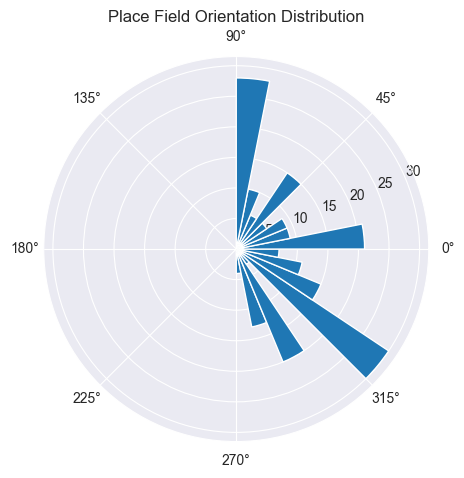

In [767]:
plt.close()
fig = plt.figure(figsize=(5, 5))
# orientations = [f['orientation'] for f in all_fields if not np.isnan(f['orientation'])]
plt.subplot(111, polar=True)
plt.hist(all_orientation, bins=16)
plt.title("Place Field Orientation Distribution")
fig.savefig(f"{cfg.snapshot.snapshot_dir}/sf_grid_action_{chosen_action_name}_seed{cfg.train.seed}_step{cfg.domain.train.num_train_frames}_place_field_orientation.pdf")
plt.show()

In [768]:
# cache out the data for population analysis
import pickle

save_path = f"{cfg.snapshot.snapshot_dir}/unit_visuals_seed{cfg.train.seed}_action_{chosen_action_name}.pkl"
with open(save_path, "wb") as f:
    pickle.dump(unit_visuals, f)

In [769]:
from collections import deque

def compute_shortest_path_distances(grid, goal_pos):
    """
    grid: 2D array where 1 = free, 0 = wall
    goal_pos: (x, y)
    Returns a 2D array of shortest distances from goal_pos
    """
    rows, cols = grid.shape
    distances = np.full((rows, cols), np.inf)
    visited = np.zeros_like(grid, dtype=bool)

    q = deque()
    gx, gy = goal_pos
    distances[gx, gy] = 0
    visited[gx, gy] = True
    q.append((gx, gy))

    while q:
        x, y = q.popleft()
        for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
            nx, ny = x+dx, y+dy
            if 0 <= nx < rows and 0 <= ny < cols and grid[nx, ny] == True and not visited[nx, ny]:
                distances[nx, ny] = distances[x, y] + 1
                visited[nx, ny] = True
                q.append((nx, ny))

    return distances

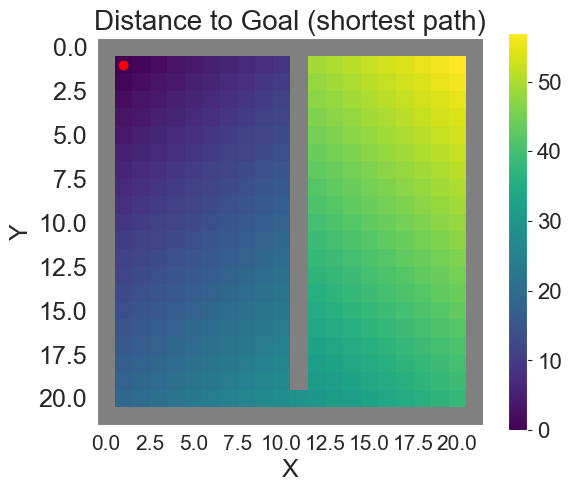

In [770]:
# create a binary map where np.nan values are 0 and non-nan values are 1.
plt.close()

cell_idx = 0 # any sf cell will do. Chose zero for convenience.
sf_current_cell = sf_tuning_curve_matrix[action, :, :, cell_idx]
sf_current_cell = sf_current_cell.T
goal_pos_inverse = (goal_pos[1], goal_pos[0])

env_map = ~ np.isnan(sf_current_cell)
dist_map = compute_shortest_path_distances(env_map, goal_pos_inverse)
dist_map_vis = np.where(np.isinf(dist_map), np.nan, dist_map)

# Mask invalid values (like NaNs)
masked_dist_map = np.ma.masked_invalid(dist_map_vis)

cmap = plt.cm.viridis.copy()
cmap.set_bad(color='grey')  # or 'black' if you prefer

# Plot
fig = plt.figure(figsize=(6, 5))
im = plt.imshow(masked_dist_map, cmap=cmap, origin='upper')
plt.plot(goal_pos[0], goal_pos[1], marker='o', color='red', markersize=6)
# plt.text(goal_pos[0] + 1, goal_pos[1] + 1, 'Goal', color='white', ha='center', va='center', fontsize=16)
plt.grid(False)
cbar = plt.colorbar(im)
cbar.set_label("", fontsize=18)
cbar.ax.tick_params(labelsize=16)
plt.title("Distance to Goal (shortest path)", fontsize=20)
plt.xlabel("X", fontsize=18)
plt.ylabel("Y", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=18)
plt.grid(False)
plt.tight_layout()
fig.savefig(f"{cfg.snapshot.snapshot_dir}/sf_grid_action_{chosen_action_name}_seed{cfg.train.seed}_step{cfg.domain.train.num_train_frames}_distance_to_goal_for_task_{task_id}.pdf")
plt.show()


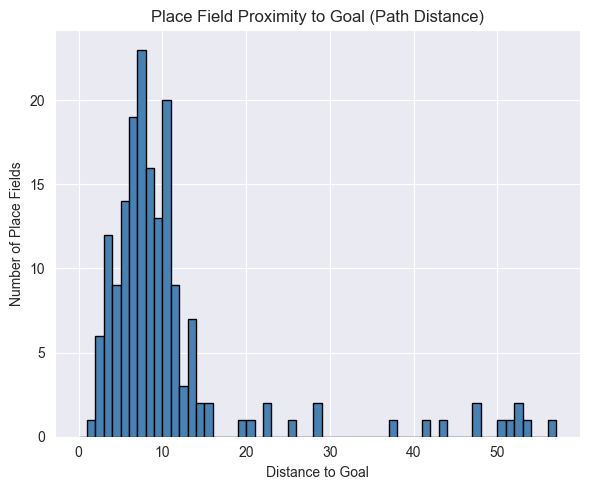

In [771]:
plt.close()

import math

fig = plt.figure(figsize=(6, 5))
distances = []

for unit in unit_visuals:
    for field in unit['place_fields']:
        y, x = field['center_of_mass']
        if not np.isnan([x, y]).any():
            y_int, x_int = int(round(y)), int(round(x))
            if np.isnan(dist_map_vis[y_int, x_int]):
                for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
                    nx, ny = x+dx, y+dy
                    y_int, x_int = int(round(ny)), int(round(nx))
                    if not np.isnan(dist_map_vis[y_int, x_int]):
                        break22
            distances.append(dist_map_vis[y_int, x_int])

plt.hist(distances, bins=range(0, int(max(distances))+2), color='steelblue', edgecolor='black')
plt.xlabel("Distance to Goal")
plt.ylabel("Number of Place Fields")
plt.title("Place Field Proximity to Goal (Path Distance)")
plt.tight_layout()
fig.savefig(f"{cfg.snapshot.snapshot_dir}/sf_grid_action_{chosen_action_name}_seed{cfg.train.seed}_step{cfg.domain.train.num_train_frames}_place_field_distance_to_goal_histogram_for_task_{task_id}.pdf")
plt.show()

In [772]:
save_path = f"{cfg.snapshot.snapshot_dir}/unit_distance_to_goal_seed{cfg.train.seed}_action_{chosen_action_name}.pkl"
with open(save_path, "wb") as f:
    pickle.dump(distances, f)

In [773]:
# load sf_tuning_curve NORTH numpy matrix
sf_tuning_curve_north_path = os.path.join(cfg.snapshot.snapshot_dir, f"sf_tuning_curve_north_task{task_id}.npy")
sf_tuning_curve_north_matrix = np.load(sf_tuning_curve_north_path)

In [774]:
# load sf_tuning_curve SOUTH numpy matrix
sf_tuning_curve_south_path = os.path.join(cfg.snapshot.snapshot_dir, f"sf_tuning_curve_south_task{task_id}.npy")
sf_tuning_curve_south_matrix = np.load(sf_tuning_curve_south_path)

In [775]:
# load sf_tuning_curve EAST numpy matrix
sf_tuning_curve_east_path = os.path.join(cfg.snapshot.snapshot_dir, f"sf_tuning_curve_east_task{task_id}.npy")
sf_tuning_curve_east_matrix = np.load(sf_tuning_curve_east_path)

In [776]:
# load sf_tuning_curve WEST numpy matrix
sf_tuning_curve_west_path = os.path.join(cfg.snapshot.snapshot_dir, f"sf_tuning_curve_west_task{task_id}.npy")
sf_tuning_curve_west_matrix = np.load(sf_tuning_curve_west_path)

In [777]:
print(sf_tuning_curve_north_matrix.shape)
print(sf_tuning_curve_south_matrix.shape)
print(sf_tuning_curve_east_matrix.shape)
print(sf_tuning_curve_west_matrix.shape)

(7, 22, 22, 128)
(7, 22, 22, 128)
(7, 22, 22, 128)
(7, 22, 22, 128)


In [778]:
sf_dim = sf_tuning_curve_north_matrix.shape[-1]
sf_tuning_curve_north_matrix_action = sf_tuning_curve_north_matrix[action, :, :, :]
sf_tuning_curve_north_matrix_action = sf_tuning_curve_north_matrix_action.reshape((-1, sf_dim))
# sf_tuning_curve_north_matrix_action = np.nan_to_num(sf_tuning_curve_north_matrix_action, nan=0.0)
sf_tuning_curve_north_matrix_action = sf_tuning_curve_north_matrix_action[~np.isnan(sf_tuning_curve_north_matrix_action).any(axis=1)]

print("sf_tuning_curve_north_matrix_action shape: ", sf_tuning_curve_north_matrix_action.shape)

sf_tuning_curve_north_matrix_action shape:  (380, 128)


In [779]:
sf_tuning_curve_south_matrix_action = sf_tuning_curve_south_matrix[action, :, :, :]
sf_tuning_curve_south_matrix_action = sf_tuning_curve_south_matrix_action.reshape((-1, sf_dim))
# sf_tuning_curve_south_matrix_action = np.nan_to_num(sf_tuning_curve_south_matrix_action, nan=0.0)
sf_tuning_curve_south_matrix_action = sf_tuning_curve_south_matrix_action[~np.isnan(sf_tuning_curve_south_matrix_action).any(axis=1)]

print("sf_tuning_curve_south_matrix_action shape: ", sf_tuning_curve_south_matrix_action.shape)

sf_tuning_curve_south_matrix_action shape:  (380, 128)


In [780]:
sf_tuning_curve_east_matrix_action = sf_tuning_curve_east_matrix[action, :, :, :]
sf_tuning_curve_east_matrix_action = sf_tuning_curve_east_matrix_action.reshape((-1, sf_dim))
# sf_tuning_curve_east_matrix_action = np.nan_to_num(sf_tuning_curve_east_matrix_action, nan=0.0)
sf_tuning_curve_east_matrix_action = sf_tuning_curve_east_matrix_action[~np.isnan(sf_tuning_curve_east_matrix_action).any(axis=1)]

print("sf_tuning_curve_east_matrix_action shape: ", sf_tuning_curve_east_matrix_action.shape)

sf_tuning_curve_east_matrix_action shape:  (380, 128)


In [781]:
sf_tuning_curve_west_matrix_action = sf_tuning_curve_west_matrix[action, :, :, :]
sf_tuning_curve_west_matrix_action = sf_tuning_curve_west_matrix_action.reshape((-1, sf_dim))
# sf_tuning_curve_west_matrix_action = np.nan_to_num(sf_tuning_curve_west_matrix_action, nan=0.0)
sf_tuning_curve_west_matrix_action = sf_tuning_curve_west_matrix_action[~np.isnan(sf_tuning_curve_west_matrix_action).any(axis=1)]

print("sf_tuning_curve_west_matrix_action shape: ", sf_tuning_curve_west_matrix_action.shape)

sf_tuning_curve_west_matrix_action shape:  (380, 128)


In [782]:
from sklearn.metrics import pairwise_distances

rdm_north = pairwise_distances(sf_tuning_curve_north_matrix_action, metric='cosine')  # or 'euclidean'
rdm_south = pairwise_distances(sf_tuning_curve_south_matrix_action, metric='cosine')
rdm_east = pairwise_distances(sf_tuning_curve_east_matrix_action, metric='cosine')
rdm_west = pairwise_distances(sf_tuning_curve_west_matrix_action, metric='cosine')


In [783]:
def vectorize_rdm(rdm):
    return rdm[np.triu_indices_from(rdm, k=1)]

In [784]:
from scipy.stats import spearmanr

direction = ["north", "south", "east", "west"]
correlation = dict()
pvalues = dict()

for dir1 in direction:
    for dir2 in direction:
        if dir1 == dir2:
            continue
        if dir1 == "north":
            vec1 = vectorize_rdm(rdm_north)
        if dir1 == "south":
            vec1 = vectorize_rdm(rdm_south)
        if dir1 == "east":
            vec1 = vectorize_rdm(rdm_east)
        if dir1 == "west":
            vec1 = vectorize_rdm(rdm_west)

        if dir2 == "north":
            vec2 = vectorize_rdm(rdm_north)
        if dir2 == "south":
            vec2 = vectorize_rdm(rdm_south)
        if dir2 == "east":
            vec2 = vectorize_rdm(rdm_east)
        if dir2 == "west":
            vec2 = vectorize_rdm(rdm_west)

        mask = ~np.isnan(vec1) & ~np.isnan(vec2)
        rho, pval = spearmanr(vec1[mask], vec2[mask])
        print(f"SF {dir1} vs SF {dir2} spearman: {rho:.3f}, p = {pval:.3g}".format(dir1=dir1, dir2=dir2, rho=rho, pval=pval))

        correlation[f"SF_{dir1}_{dir2}".format(dir1=dir1, dir2=dir2)] = rho
        pvalues[f"SF_{dir1}_{dir2}"] = pval

print(correlation.keys())
print(pvalues.keys())

SF north vs SF south spearman: 0.638, p = 0
SF north vs SF east spearman: 0.650, p = 0
SF north vs SF west spearman: 0.575, p = 0
SF south vs SF north spearman: 0.638, p = 0
SF south vs SF east spearman: 0.616, p = 0
SF south vs SF west spearman: 0.611, p = 0
SF east vs SF north spearman: 0.650, p = 0
SF east vs SF south spearman: 0.616, p = 0
SF east vs SF west spearman: 0.588, p = 0
SF west vs SF north spearman: 0.575, p = 0
SF west vs SF south spearman: 0.611, p = 0
SF west vs SF east spearman: 0.588, p = 0
dict_keys(['SF_north_south', 'SF_north_east', 'SF_north_west', 'SF_south_north', 'SF_south_east', 'SF_south_west', 'SF_east_north', 'SF_east_south', 'SF_east_west', 'SF_west_north', 'SF_west_south', 'SF_west_east'])
dict_keys(['SF_north_south', 'SF_north_east', 'SF_north_west', 'SF_south_north', 'SF_south_east', 'SF_south_west', 'SF_east_north', 'SF_east_south', 'SF_east_west', 'SF_west_north', 'SF_west_south', 'SF_west_east'])


In [785]:
correlation_save_path = f"{cfg.snapshot.snapshot_dir}/correlation_seed{cfg.train.seed}_action_{chosen_action_name}.pkl"
with open(correlation_save_path, "wb") as f:
    pickle.dump(correlation, f)

In [786]:
pvalues_save_path = f"{cfg.snapshot.snapshot_dir}/pvalues_seed{cfg.train.seed}_action_{chosen_action_name}.pkl"
with open(pvalues_save_path, "wb") as f:
    pickle.dump(pvalues, f)

(380, 380)


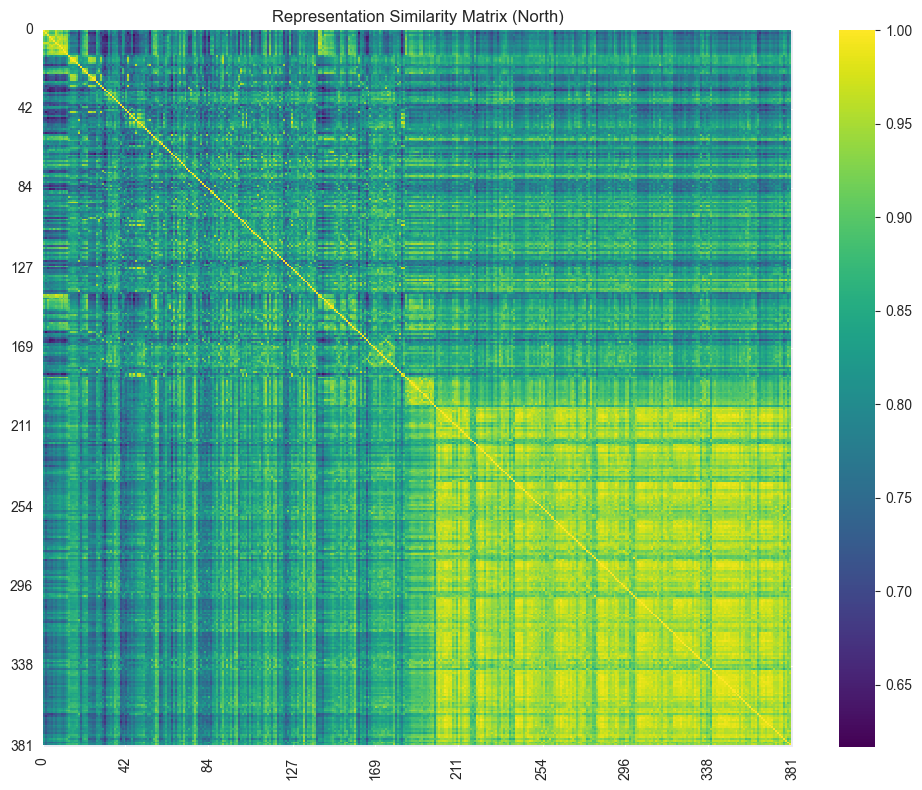

In [787]:
# compute RSA matrix
from sklearn.metrics.pairwise import cosine_similarity
# Compute similarity matrix
sf_tuning_curve_north_similarity_matrix = cosine_similarity(sf_tuning_curve_north_matrix_action)
print(sf_tuning_curve_north_similarity_matrix.shape)  # should be (382, 382)

# Set figure size (optional)
plt.figure(figsize=(10, 8))

# Generate heatmap
ax = sns.heatmap(
    sf_tuning_curve_north_similarity_matrix,
    cmap='viridis',
    xticklabels=True,
    yticklabels=True
)

# Set consistent axis labels
num_ticks = 10  # or 20, depending on density
tick_positions = np.linspace(0, 381, num_ticks, dtype=int)
tick_labels = [str(i) for i in tick_positions]

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90)
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels, rotation=0)

# Title and save
plt.title("Representation Similarity Matrix (North)")
plt.tight_layout()
plt.savefig(f"{cfg.snapshot.snapshot_dir}/RSA_north_seed{cfg.train.seed}_action_{chosen_action_name}.pdf")
plt.show()

(380, 380)


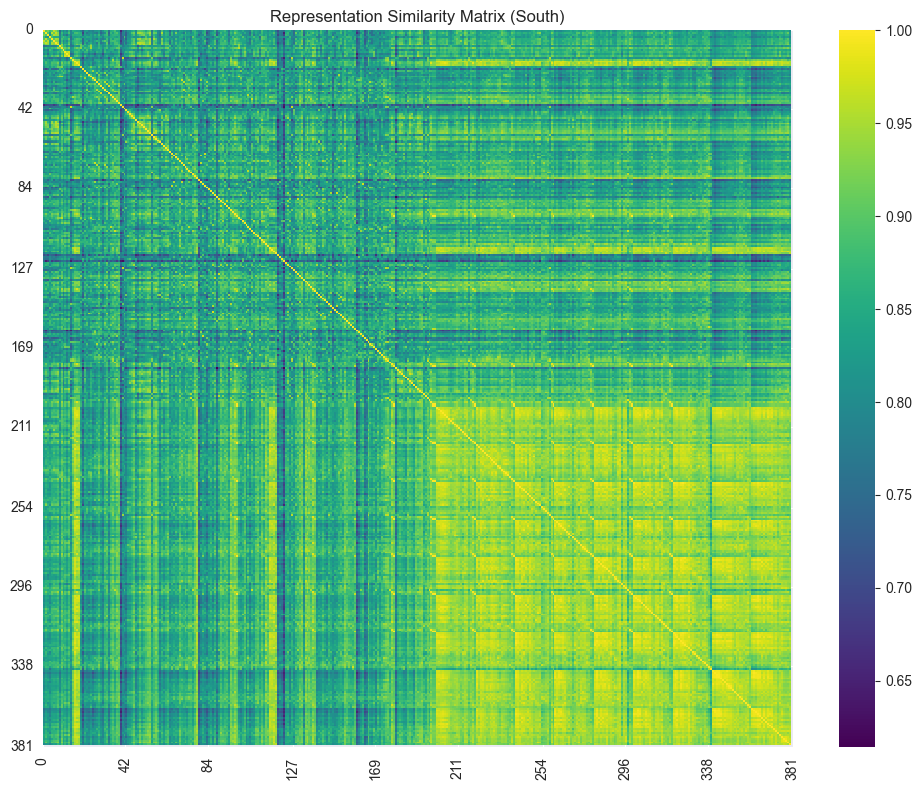

In [788]:
plt.close()

# Compute similarity matrix
sf_tuning_curve_south_similarity_matrix = cosine_similarity(sf_tuning_curve_south_matrix_action)
print(sf_tuning_curve_south_similarity_matrix.shape)  # should be (382, 382)

# Set figure size (optional)
plt.figure(figsize=(10, 8))

# Generate heatmap
ax = sns.heatmap(
    sf_tuning_curve_south_similarity_matrix,
    cmap='viridis',
    xticklabels=True,
    yticklabels=True
)

# Set consistent axis labels
num_ticks = 10  # or 20, depending on density
tick_positions = np.linspace(0, 381, num_ticks, dtype=int)
tick_labels = [str(i) for i in tick_positions]

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90)
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels, rotation=0)

# Title and save
plt.title("Representation Similarity Matrix (South)")
plt.tight_layout()
plt.savefig(f"{cfg.snapshot.snapshot_dir}/RSA_south_seed{cfg.train.seed}_action_{chosen_action_name}.pdf")
plt.show()

(380, 380)


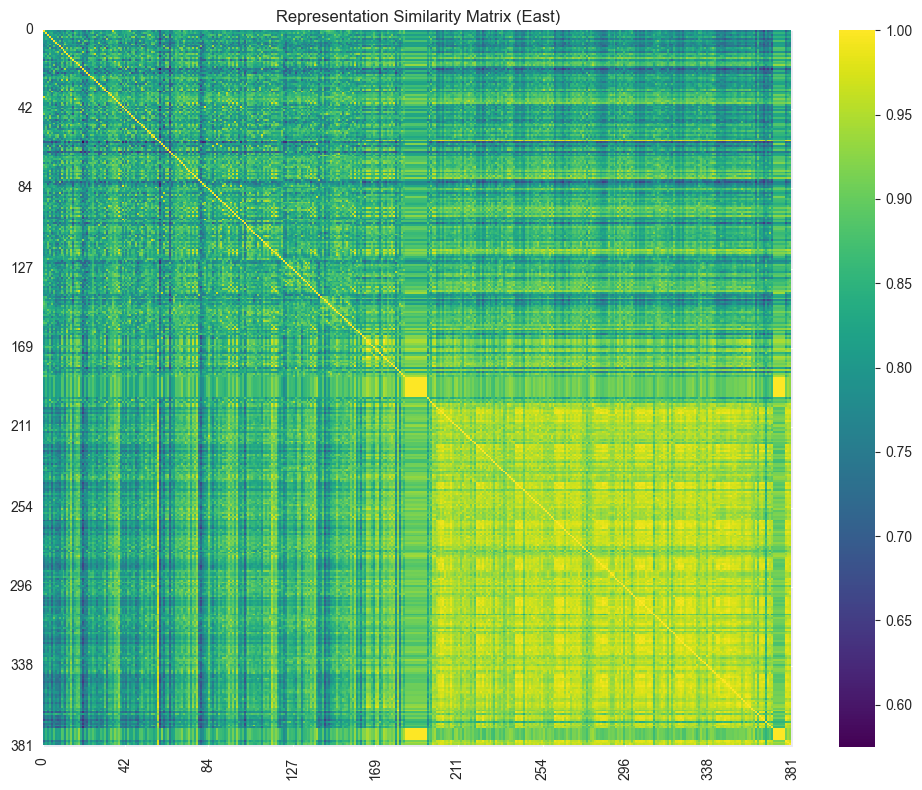

In [789]:
plt.close()

# Compute similarity matrix
sf_tuning_curve_east_similarity_matrix = cosine_similarity(sf_tuning_curve_east_matrix_action)
print(sf_tuning_curve_east_similarity_matrix.shape)  # should be (382, 382)

# Set figure size (optional)
plt.figure(figsize=(10, 8))

# Generate heatmap
ax = sns.heatmap(
    sf_tuning_curve_east_similarity_matrix,
    cmap='viridis',
    xticklabels=True,
    yticklabels=True
)

# Set consistent axis labels
num_ticks = 10  # or 20, depending on density
tick_positions = np.linspace(0, 381, num_ticks, dtype=int)
tick_labels = [str(i) for i in tick_positions]

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90)
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels, rotation=0)

# Title and save
plt.title("Representation Similarity Matrix (East)")
plt.tight_layout()
plt.savefig(f"{cfg.snapshot.snapshot_dir}/RSA_east_seed{cfg.train.seed}_action_{chosen_action_name}.pdf")
plt.show()

(380, 380)


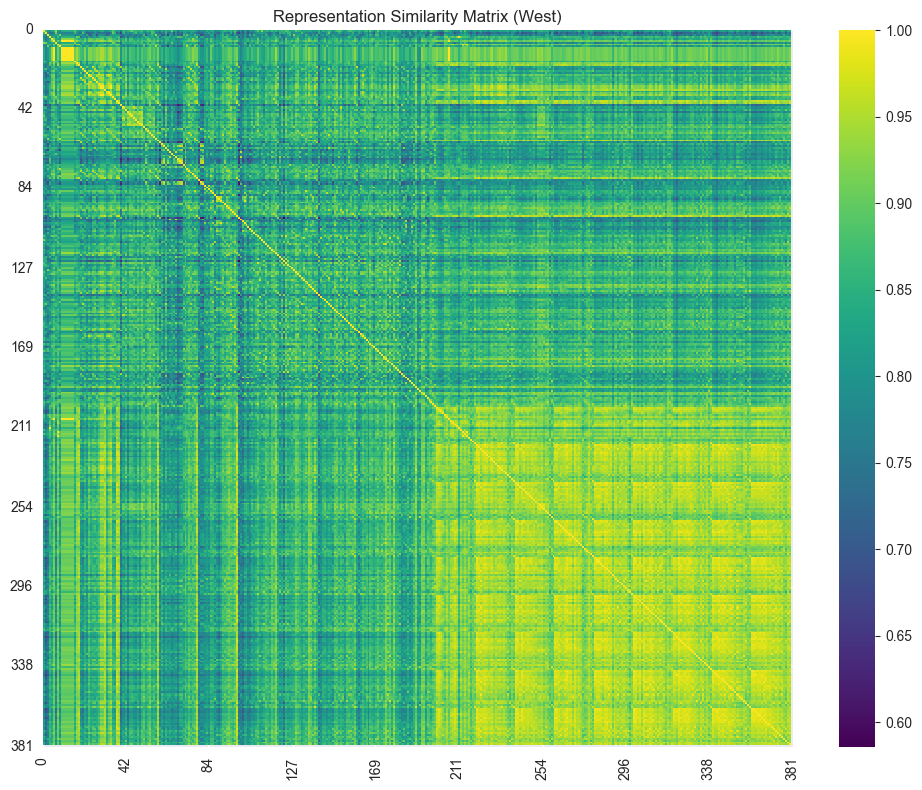

In [790]:
plt.close()

# Compute similarity matrix
sf_tuning_curve_west_similarity_matrix = cosine_similarity(sf_tuning_curve_west_matrix_action)
print(sf_tuning_curve_west_similarity_matrix.shape)  # should be (382, 382)

# Set figure size (optional)
plt.figure(figsize=(10, 8))

# Generate heatmap
ax = sns.heatmap(
    sf_tuning_curve_west_similarity_matrix,
    cmap='viridis',
    xticklabels=True,
    yticklabels=True
)

# Set consistent axis labels
num_ticks = 10  # or 20, depending on density
tick_positions = np.linspace(0, 381, num_ticks, dtype=int)
tick_labels = [str(i) for i in tick_positions]

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90)
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels, rotation=0)

# Title and save
plt.title("Representation Similarity Matrix (West)")
plt.tight_layout()
plt.savefig(f"{cfg.snapshot.snapshot_dir}/RSA_west_seed{cfg.train.seed}_action_{chosen_action_name}.pdf")
plt.show()

In [791]:
plt.close()

grid_size = cfg.domain.grid_size
env = workspace.train_task.get_env(task_id=0)
env_mask = np.zeros((grid_size, grid_size))
unavailable_cells = 0

for x in range(grid_size):
    for y in range(grid_size):

        timestep, cell = env.reset_with_agent_pos_dir(
            agent_pos=(x, y),
            agent_dir=0, # head direction does not really matter in this case
            top_down_view=cfg.domain.top_down_view,
            tile_size=cfg.domain.tile_size,
        )

        if cell is not None and cell.type in {"goal", "lava", "wall"}:
            env_mask[x, y] = 1
            unavailable_cells += 1

# remove the border around the environment
# env_mask = env_mask[1:-1, 1:-1]
env_mask = env_mask.T

print(env_mask.shape)

assert np.sum(env_mask) > 0
assert unavailable_cells == np.sum(env_mask)

(22, 22)


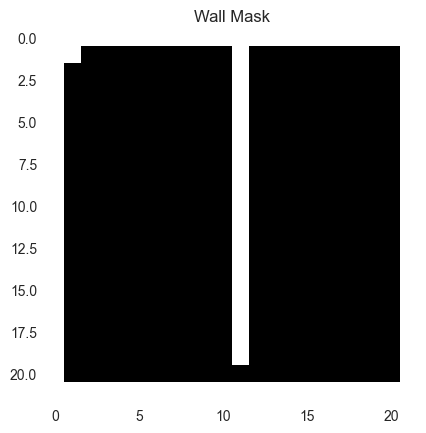

In [792]:
env_mask_bool = env_mask.astype(bool)
env_mask_walls = env_mask_bool     # if 1 = wall
env_mask_free = ~env_mask_bool     # inverts wall to free space
plt.imshow(env_mask_walls, cmap='gray')
plt.title("Wall Mask")
plt.grid(False)
plt.savefig(f"{cfg.snapshot.snapshot_dir}/wall_mask.pdf")
plt.show()

In [793]:
plt.close()

from scipy.ndimage import distance_transform_edt
dist_to_wall_map = distance_transform_edt(~env_mask_walls)

distances_to_wall = []

for unit in unit_visuals:
    for field in unit['place_fields']:
        y, x = field['center_of_mass']
        if not np.isnan([x, y]).any():
            y_int, x_int = int(round(y)), int(round(x))

            # Handle edge cases where location is invalid
            if np.isnan(dist_to_wall_map[y_int, x_int]):
                for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
                    nx, ny = x+dx, y+dy
                    y_int, x_int = int(round(ny)), int(round(nx))
                    if not np.isnan(dist_to_wall_map[y_int, x_int]):
                        break

            distances_to_wall.append(dist_to_wall_map[y_int, x_int])

In [794]:
def compute_border_scores(unit_visuals, env_mask_walls):
    # Step 0: Precompute distance to nearest wall for all spatial bins
    dist_to_wall_map = distance_transform_edt(~env_mask_walls)

    unit_border_scores = []

    for unit in unit_visuals:
        unit_scores = []

        for field in unit['place_fields']:
            field_mask = field['mask']
            y, x = field['center_of_mass']

            # Skip if CoM is NaN
            if np.isnan([y, x]).any():
                continue

            y_int, x_int = int(round(y)), int(round(x))

            # Edge case: if outside bounds or NaN in distance map
            try:
                if np.isnan(dist_to_wall_map[y_int, x_int]):
                    # Try neighbors
                    found_valid = False
                    for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
                        nx, ny = int(round(x + dx)), int(round(y + dy))
                        if 0 <= ny < dist_to_wall_map.shape[0] and 0 <= nx < dist_to_wall_map.shape[1]:
                            if not np.isnan(dist_to_wall_map[ny, nx]):
                                y_int, x_int = ny, nx
                                found_valid = True
                                break
                    if not found_valid:
                        continue
            except IndexError:
                continue

            # Compute d_mean = distance from field center to nearest wall
            d_mean = dist_to_wall_map[y_int, x_int]

            # extend field_mask because it it did not include the walls around the environment
            # field_mask_extended = np.zeros((field_mask.shape[0]+2, field_mask.shape[1]+2))
            # field_mask_extended[1:-1, 1:-1] = field_mask

            # Compute d_max = number of field pixels adjacent to wall
            dilated = binary_dilation(field_mask, structure=np.ones((3,3)))
            contact_area = np.logical_and(dilated, env_mask_walls)
            d_max = np.sum(contact_area)

            # Compute border score
            eps = 1e-8
            border_score = (d_max - d_mean) / (d_max + d_mean + eps)

            # Store result
            unit_scores.append({
                'center_of_mass': (y, x),
                'border_score': border_score,
                'd_mean': d_mean,
                'd_max': d_max
            })

        unit_border_scores.append({
            'unit_index': unit.get('unit_id', None),
            'field_scores': unit_scores
        })

    return unit_border_scores

In [795]:
# Assume you have this output already
border_scores_all_units = compute_border_scores(unit_visuals, env_mask_walls)

# Collect all border scores across units and fields
all_border_scores = []

for unit_result in border_scores_all_units:
    for field in unit_result['field_scores']:
        all_border_scores.append(field['border_score'])

all_border_scores = np.array(all_border_scores)

In [796]:
# Boolean masks
is_border = all_border_scores >= 0.5
is_non_border = all_border_scores < 0.5

# Counts
num_border_cells = np.sum(is_border)
num_non_border_cells = np.sum(is_non_border)
percentage_border = num_border_cells / (num_border_cells + num_non_border_cells)
print("number of border cells for simple SF: ", num_border_cells)
print("number of non border cells for simple SF: ",num_non_border_cells)

print("percentage of border cells for simple SF: ", percentage_border)

save_path_text = f"{cfg.snapshot.snapshot_dir}/num_border_cells_stats_seed{cfg.train.seed}_action_{chosen_action_name}.txt"

with open(save_path_text, 'w') as f:
    f.write(f"Number of border cells for simple SF: {num_border_cells}\n")
    f.write(f"Number of non-border cells for simple SF: {num_non_border_cells}\n")
    f.write(f"Percentage of border cells for simple SF: {percentage_border:.4f}\n")

results_dict = {
    "num_border_cells": int(num_border_cells),
    "num_non_border_cells": int(num_non_border_cells),
    "percentage_border_cells": float(percentage_border),
}

save_path_dict = f"{cfg.snapshot.snapshot_dir}/border_cells_stats_seed{cfg.train.seed}_action_{chosen_action_name}.pkl"

with open(save_path_dict, "wb") as f:
    pickle.dump(results_dict, f)


number of border cells for simple SF:  34
number of non border cells for simple SF:  140
percentage of border cells for simple SF:  0.19540229885057472


In [797]:
save_path = f"{cfg.snapshot.snapshot_dir}/border_scores_all_units_seed{cfg.train.seed}_action_{chosen_action_name}.pkl"
with open(save_path, "wb") as f:
    pickle.dump(border_scores_all_units, f)

In [798]:
border_threshold = 0.5 # based on Solstad et al. 2008 Representation of Geometric Borders in the Entorhinal Cortex

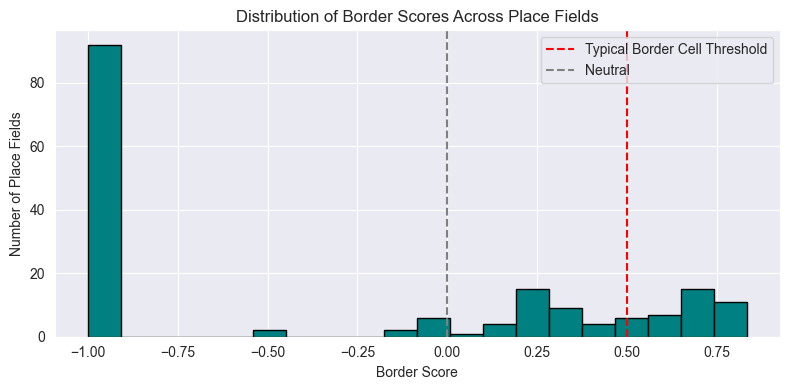

In [799]:
plt.figure(figsize=(8, 4))
plt.hist(all_border_scores, bins=20, color='teal', edgecolor='black')
plt.xlabel("Border Score")
plt.ylabel("Number of Place Fields")
plt.title("Distribution of Border Scores Across Place Fields")
plt.grid(True)
plt.axvline(border_threshold, color='red', linestyle='--', label='Typical Border Cell Threshold')
plt.axvline(0.0, color='gray', linestyle='--', label='Neutral')
plt.legend()
plt.tight_layout()
plt.savefig(f"{cfg.snapshot.snapshot_dir}/border_score_{cfg.train.seed}_action_{chosen_action_name}.pdf")
plt.show()

In [800]:
num_total = len(all_border_scores)
num_border_like = np.sum(all_border_scores > border_threshold)

print(f"{num_border_like}/{num_total} place fields ({100*num_border_like/num_total:.1f}%) are border-aligned.")

34/174 place fields (19.5%) are border-aligned.


In [801]:
border_fields_to_plot = []

for unit_data, score_data in zip(unit_visuals, border_scores_all_units):
    unit_fields = unit_data['place_fields']
    field_scores = score_data['field_scores']

    for field, score in zip(unit_fields, field_scores):
        if score['border_score'] > border_threshold:
            border_fields_to_plot.append({
                'sf_map': unit_data['sf_map'],
                'mask': field['mask'],
                'center_of_mass': field['center_of_mass'],
                'border_score': score['border_score'],
            })

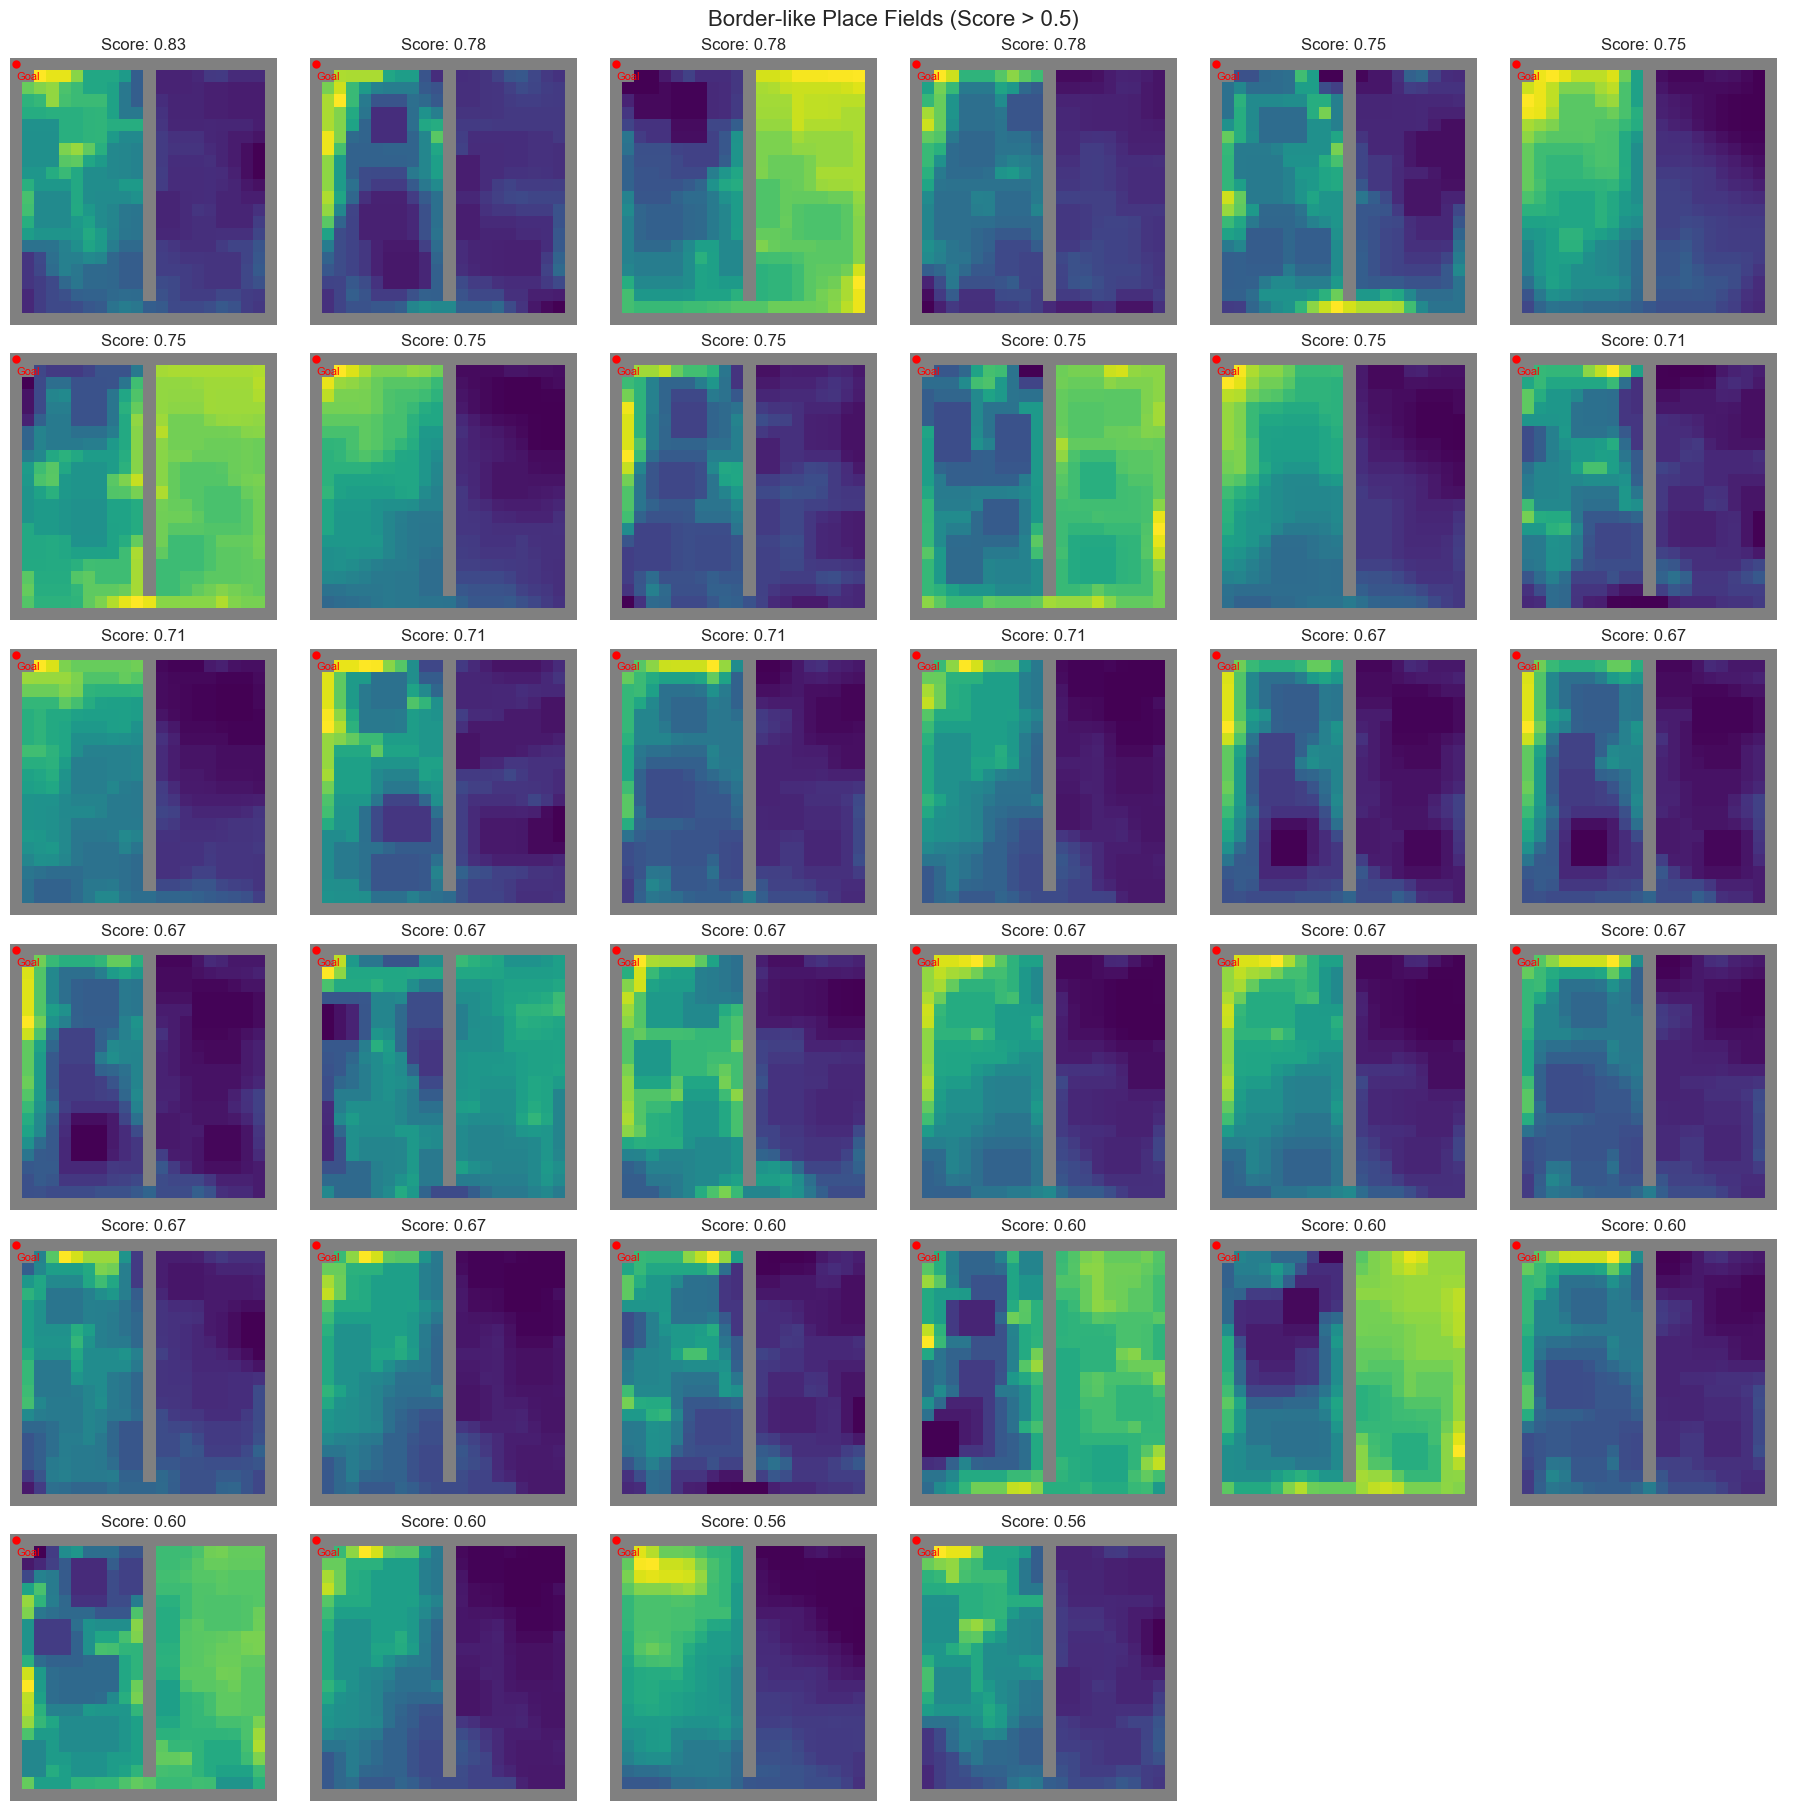

In [802]:
num_fields = len(border_fields_to_plot)
num_cols = 6
num_rows = (num_fields + num_cols - 1) // num_cols

fig, axs = plt.subplots(num_rows, num_cols, figsize=(3*num_cols, 3*num_rows), constrained_layout=True)

border_fields_to_plot_sorted = sorted(border_fields_to_plot, key=lambda d: d['border_score'], reverse=True)

for idx, field in enumerate(border_fields_to_plot_sorted):
    row, col = divmod(idx, num_cols)
    ax = axs[row, col] if num_rows > 1 else axs[col]

    sf_map = field['sf_map']
    mask = field['mask']
    com = field['center_of_mass']
    score = field['border_score']

    im = ax.imshow(sf_map, cmap=cmap)
    sf_map_masked = np.ma.masked_invalid(sf_map)

    # ax.contour(mask, levels=[0.5], colors='blue')  # draw mask boundary
    # ax.plot(com[1], com[0], 'wo')  # white dot = CoM
    ax.set_title(f"Score: {score:.2f}")
    ax.axis('off')
    ax.plot(goal_pos_corrected[0], goal_pos_corrected[1], marker='o', color='red', markersize=5)
    ax.text(goal_pos_corrected[0] + 1, goal_pos_corrected[1] + 1, 'Goal', color='red', ha='center', va='center', fontsize=8)

# Hide unused subplots
for k in range(idx+1, num_rows * num_cols):
    row, col = divmod(k, num_cols)
    ax = axs[row, col] if num_rows > 1 else axs[col]
    ax.axis('off')

# Use the last imshow as reference for color scale
cmap = plt.cm.get_cmap('viridis').copy()
# cmap.set_bad(color='black')

if len(axs.shape) == 1:
    # Create a hidden AxesImage to grab the color scale
    dummy_img = axs[0].imshow(sf_map_masked, cmap=cmap)

else:
    dummy_img = axs[0, 0].imshow(sf_map_masked, cmap=cmap)


plt.suptitle(f"Border-like Place Fields (Score > {border_threshold})", fontsize=16)
plt.savefig(f"{cfg.snapshot.snapshot_dir}/border_like_place_fields_{cfg.train.seed}_action_{chosen_action_name}.pdf")
plt.show()